In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
# Load telco customer churn dataset
data = pd.read_csv('Telco-Customer-Churn.csv')
selected_features = ['customerID', 'gender', 'tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'] 
telco_df = data[selected_features].copy()

# Inspect the Data
print(telco_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7043 non-null   object 
 1   gender          7043 non-null   object 
 2   tenure          7043 non-null   int64  
 3   Contract        7043 non-null   object 
 4   PaymentMethod   7043 non-null   object 
 5   MonthlyCharges  7043 non-null   float64
 6   TotalCharges    7043 non-null   object 
 7   Churn           7043 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 440.3+ KB
None


In [3]:
print(telco_df.describe())
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')
telco_df['TotalCharges'] = telco_df['TotalCharges'].fillna(telco_df['TotalCharges'].median())
telco_df.head()

            tenure  MonthlyCharges
count  7043.000000     7043.000000
mean     32.371149       64.761692
std      24.559481       30.090047
min       0.000000       18.250000
25%       9.000000       35.500000
50%      29.000000       70.350000
75%      55.000000       89.850000
max      72.000000      118.750000


,customerID,gender,tenure,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,1,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,34,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,2,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,45,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,2,Month-to-month,Electronic check,70.70,151.65,Yes


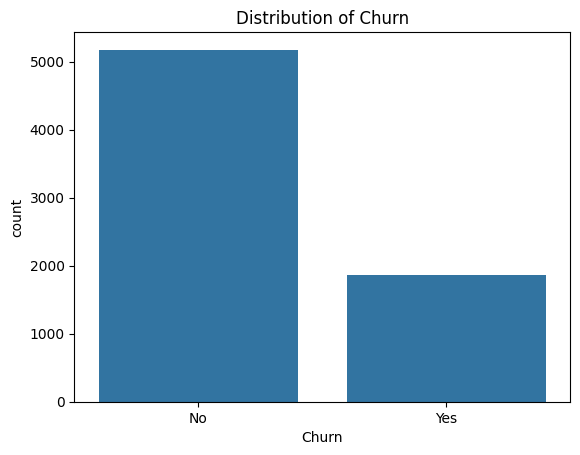

In [4]:
# Visualize the distribution of churn
sns.countplot(x='Churn', data=telco_df)
plt.title('Distribution of Churn')
plt.show()

In [5]:
# Encode categorical variables
le = LabelEncoder()
telco_df['Churn'] = le.fit_transform(telco_df['Churn'])

# Define features and target variable
X = telco_df.drop(columns=['Churn', 'customerID', 'gender', 'Contract', 'PaymentMethod'])  
y = telco_df['Churn']

# Scale the features
scale = StandardScaler()
X_scaled = scale.fit_transform(X)


In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [7]:
# Train Logistic Regression model
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

# Train K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [8]:
# Evaluate Models
log_pred = log_model.predict(X_test)
knn_pred = knn_model.predict(X_test)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, log_pred))
print("\nK-Nearest Neighbors Classification Report:")
print(classification_report(y_test, knn_pred))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.48      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409


K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.63      0.50      0.56       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [9]:
# Confusion Matrix for Logistic Regression
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, log_pred))

Logistic Regression Confusion Matrix:
 [[945  91]
 [194 179]]
